# Exploratory Data Analysis

This notebook investigates factors that influence customer churn.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned/customer_clean.csv")

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

## How serious is the churn problem?

In [3]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

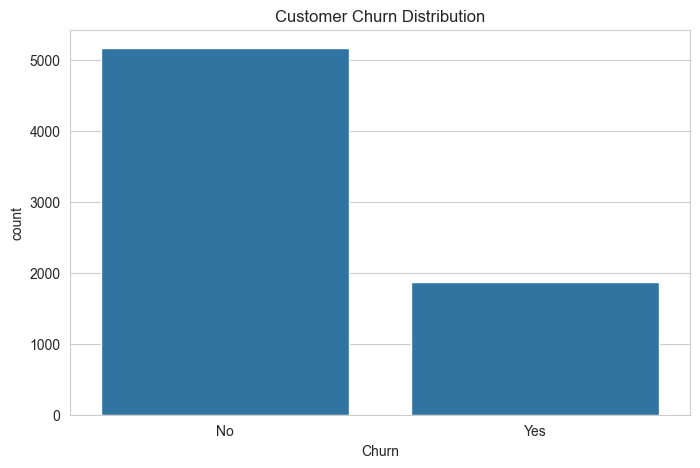

In [4]:
sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

## Observation

Out of 7043 customers, 1869 customers have churned while 5174 remain active.

The overall churn rate is approximately 26.54%, meaning nearly one out of every four customers leaves the company's services.

This indicates a significant customer retention challenge and highlights the importance of understanding the factors driving churn.

## Do contract types influence churn?

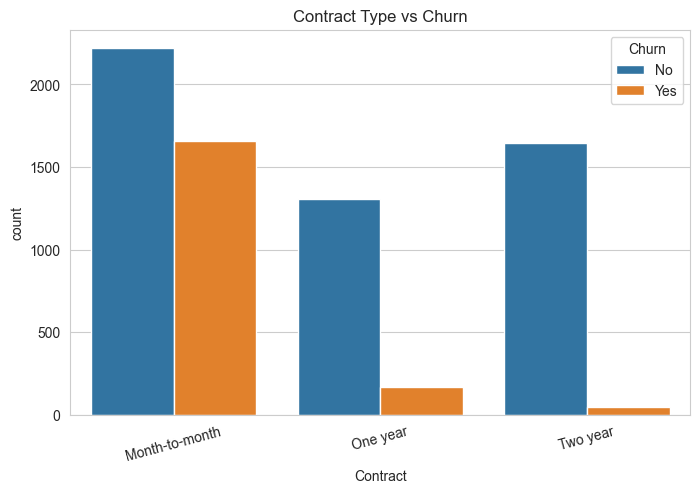

In [5]:
sns.countplot(
    x="Contract",
    hue="Churn",
    data=df
)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)
plt.show()

## Observation

Customers with month-to-month contracts exhibit the highest churn levels compared to customers with one-year and two-year contracts.

Customers on long-term contracts are significantly more likely to remain with the company.

This suggests that contract commitment plays a major role in customer retention and may be one of the strongest predictors of churn in the dataset.

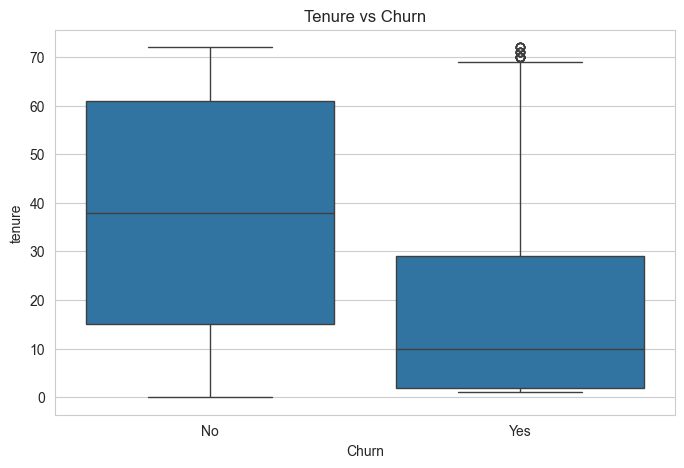

In [6]:
sns.boxplot(
    x="Churn",
    y="tenure",
    data=df
)

plt.title("Tenure vs Churn")
plt.show()

## Observation

Customers who churn generally have a much lower tenure than customers who remain active.

The median tenure of retained customers is substantially higher than that of churned customers.

This suggests that newer customers are more vulnerable to leaving the service, while long-term customers tend to be more loyal.

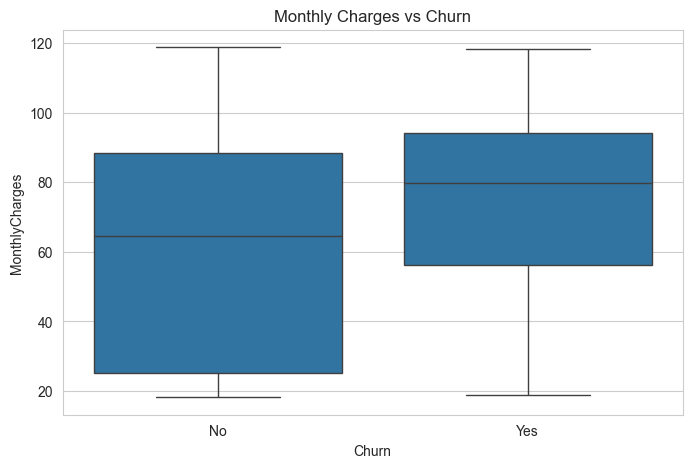

In [7]:
sns.boxplot(
    x="Churn",
    y="MonthlyCharges",
    data=df
)

plt.title("Monthly Charges vs Churn")
plt.show()

## Observation

Customers who churn tend to have higher monthly charges on average compared to customers who remain active.

The median monthly charge for churned customers is noticeably higher than that of retained customers.

This may indicate that pricing, perceived value, or service expectations influence customer retention.

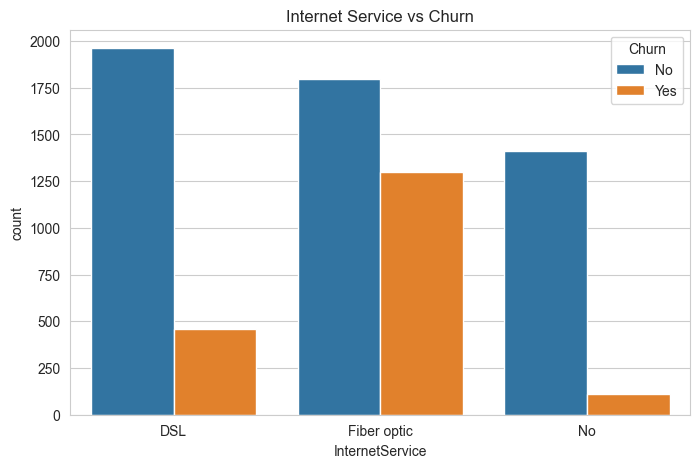

In [8]:
sns.countplot(
    x="InternetService",
    hue="Churn",
    data=df
)

plt.title("Internet Service vs Churn")
plt.show()

## Observation

Fiber optic customers account for the highest number of churned customers among all internet service categories.

DSL customers show lower churn levels, while customers without internet service exhibit the lowest churn levels.

This suggests that fiber optic customers may require further investigation regarding pricing, competition, service quality, or customer satisfaction.

In [9]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


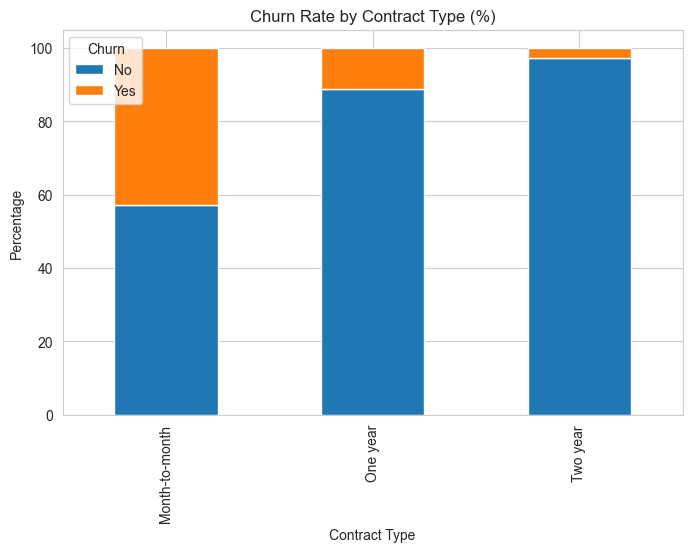

In [10]:
contract_churn.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type (%)")
plt.ylabel("Percentage")
plt.xlabel("Contract Type")
plt.legend(title="Churn")
plt.show()

# Key Findings from EDA

1. The overall churn rate is 26.54%.

2. Month-to-month customers are significantly more likely to churn than customers on long-term contracts.

3. Customers with low tenure are at the highest risk of churn.

4. Customers paying higher monthly charges tend to churn more frequently.

5. Fiber optic internet customers represent the largest proportion of churned customers.

## Preliminary High-Risk Customer Profile

A high-risk customer is likely to:
- Be on a month-to-month contract
- Have low tenure
- Pay higher monthly charges
- Use fiber optic internet service

These insights will guide the customer segmentation and risk scoring phases of the project.